In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv(r'C:\Users\hardi\OneDrive\Desktop\marketing_project\marketing_campaign_performance.csv')

# First look at your data
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nBasic stats:")
print(df.describe())

Shape of dataset: (200000, 16)

Column names:
['Campaign_ID', 'Company', 'Campaign_Type', 'Target_Audience', 'Duration', 'Channel_Used', 'Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Location', 'Language', 'Clicks', 'Impressions', 'Engagement_Score', 'Customer_Segment', 'Date']

First 5 rows:
   Campaign_ID              Company Campaign_Type Target_Audience Duration  \
0            1  Innovate Industries         Email       Men 18-24  30 days   
1            2       NexGen Systems         Email     Women 35-44  60 days   
2            3    Alpha Innovations    Influencer       Men 25-34  30 days   
3            4   DataTech Solutions       Display        All Ages  60 days   
4            5       NexGen Systems         Email       Men 25-34  15 days   

  Channel_Used  Conversion_Rate Acquisition_Cost   ROI     Location  Language  \
0   Google Ads             0.04       $16,174.00  6.29      Chicago   Spanish   
1   Google Ads             0.12       $11,566.00  5.61     New York    Ger

In [15]:
# ---- 1. Fix Acquisition_Cost (remove $ and commas, convert to float)
df['Acquisition_Cost'] = df['Acquisition_Cost'].str.replace('$', '', regex=False)
df['Acquisition_Cost'] = df['Acquisition_Cost'].str.replace(',', '', regex=False)
df['Acquisition_Cost'] = df['Acquisition_Cost'].astype(float)

# ---- 2. Fix Date column
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month_name()
df['Year'] = df['Date'].dt.year
df['Month_Num'] = df['Date'].dt.month

# ---- 3. Fix Duration (extract just the number)
df['Duration_Days'] = df['Duration'].str.extract('(\d+)').astype(int)

# ---- 4. Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# ---- 5. Add calculated columns (KPIs we'll use in dashboard)
df['CTR'] = (df['Clicks'] / df['Impressions']) * 100               # Click Through Rate %
df['Revenue'] = df['ROI'] * df['Acquisition_Cost']                  # Estimated Revenue
df['Cost_Per_Click'] = df['Acquisition_Cost'] / df['Clicks']        # CPC

# ---- 6. Confirm everything looks good
print("\nCleaned data types:")
print(df.dtypes)
print("\nFirst 3 rows after cleaning:")
print(df[['Campaign_ID', 'Acquisition_Cost', 'Date', 'Duration_Days', 'CTR', 'Revenue', 'Cost_Per_Click']].head(3))

<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
C:\Users\hardi\AppData\Local\Temp\ipykernel_30516\2505207760.py:13: SyntaxWarning: invalid escape sequence '\d'
  df['Duration_Days'] = df['Duration'].str.extract('(\d+)').astype(int)


Missing values in each column:
Campaign_ID         0
Company             0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Conversion_Rate     0
Acquisition_Cost    0
ROI                 0
Location            0
Language            0
Clicks              0
Impressions         0
Engagement_Score    0
Customer_Segment    0
Date                0
Month               0
Year                0
Month_Num           0
Duration_Days       0
dtype: int64

Cleaned data types:
Campaign_ID                  int64
Company                     object
Campaign_Type               object
Target_Audience             object
Duration                    object
Channel_Used                object
Conversion_Rate            float64
Acquisition_Cost           float64
ROI                        float64
Location                    object
Language                    object
Clicks                       int64
Impressions                  int64
Engagement_Score             int64
Custo

In [17]:
# Install pandasql
import subprocess
subprocess.run(['pip', 'install', 'pandasql'], capture_output=True)

from pandasql import sqldf
pysqldf = lambda q: sqldf(q, globals())

In [20]:
from pandasql import sqldf
pysqldf = lambda q: sqldf(q, globals())

# Query 1: Best Performing Channels by ROI
q1 = """
SELECT 
    Channel_Used,
    COUNT(*) as Total_Campaigns,
    ROUND(AVG(ROI), 2) as Avg_ROI,
    ROUND(AVG(Conversion_Rate) * 100, 2) as Avg_Conversion_Rate_Pct,
    ROUND(AVG(Acquisition_Cost), 2) as Avg_Cost,
    ROUND(SUM(Revenue), 2) as Total_Revenue
FROM df
GROUP BY Channel_Used
ORDER BY Avg_ROI DESC
"""
result1 = pysqldf(q1)
print("=== BEST PERFORMING CHANNELS ===")
print(result1)

# Query 2: Best Campaign Types
q2 = """
SELECT 
    Campaign_Type,
    COUNT(*) as Total_Campaigns,
    ROUND(AVG(ROI), 2) as Avg_ROI,
    ROUND(AVG(Conversion_Rate) * 100, 2) as Avg_Conversion_Rate_Pct,
    ROUND(SUM(Revenue), 2) as Total_Revenue,
    ROUND(AVG(Acquisition_Cost), 2) as Avg_Cost
FROM df
GROUP BY Campaign_Type
ORDER BY Total_Revenue DESC
"""
result2 = pysqldf(q2)
print("\n=== BEST CAMPAIGN TYPES ===")
print(result2)

# Query 3: Month on Month Performance
q3 = """
SELECT 
    Year,
    Month,
    Month_Num,
    COUNT(*) as Total_Campaigns,
    ROUND(SUM(Revenue), 2) as Total_Revenue,
    ROUND(SUM(Acquisition_Cost), 2) as Total_Spend,
    ROUND(AVG(ROI), 2) as Avg_ROI,
    ROUND(AVG(Conversion_Rate) * 100, 2) as Avg_Conversion_Pct
FROM df
GROUP BY Year, Month, Month_Num
ORDER BY Year, Month_Num
"""
result3 = pysqldf(q3)
print("\n=== MONTH ON MONTH PERFORMANCE ===")
print(result3)

# Query 4: Cost Per Click by Channel
q4 = """
SELECT 
    Channel_Used,
    ROUND(AVG(Cost_Per_Click), 2) as Avg_CPC,
    ROUND(AVG(CTR), 2) as Avg_CTR_Pct,
    ROUND(AVG(Engagement_Score), 2) as Avg_Engagement,
    SUM(Clicks) as Total_Clicks,
    SUM(Impressions) as Total_Impressions
FROM df
GROUP BY Channel_Used
ORDER BY Avg_CPC ASC
"""
result4 = pysqldf(q4)
print("\n=== COST EFFICIENCY BY CHANNEL ===")
print(result4)

# Query 5: Top Performing Customer Segments
q5 = """
SELECT 
    Customer_Segment,
    COUNT(*) as Total_Campaigns,
    ROUND(AVG(ROI), 2) as Avg_ROI,
    ROUND(AVG(Conversion_Rate) * 100, 2) as Avg_Conversion_Pct,
    ROUND(SUM(Revenue), 2) as Total_Revenue
FROM df
GROUP BY Customer_Segment
ORDER BY Total_Revenue DESC
"""
result5 = pysqldf(q5)
print("\n=== TOP CUSTOMER SEGMENTS ===")
print(result5)

=== BEST PERFORMING CHANNELS ===
  Channel_Used  Total_Campaigns  Avg_ROI  Avg_Conversion_Rate_Pct  Avg_Cost  \
0     Facebook            32819     5.02                     8.00  12510.90   
1      Website            33360     5.01                     8.02  12487.81   
2   Google Ads            33438     5.00                     8.02  12528.03   
3        Email            33599     5.00                     8.03  12526.39   
4      YouTube            33392     4.99                     7.99  12481.39   
5    Instagram            33392     4.99                     7.99  12491.76   

   Total_Revenue  
0   2.063945e+09  
1   2.087559e+09  
2   2.097811e+09  
3   2.103770e+09  
4   2.084326e+09  
5   2.079977e+09  

=== BEST CAMPAIGN TYPES ===
  Campaign_Type  Total_Campaigns  Avg_ROI  Avg_Conversion_Rate_Pct  \
0    Influencer            40169     5.01                     8.03   
1        Search            40157     5.01                     8.00   
2       Display            39987     5.01

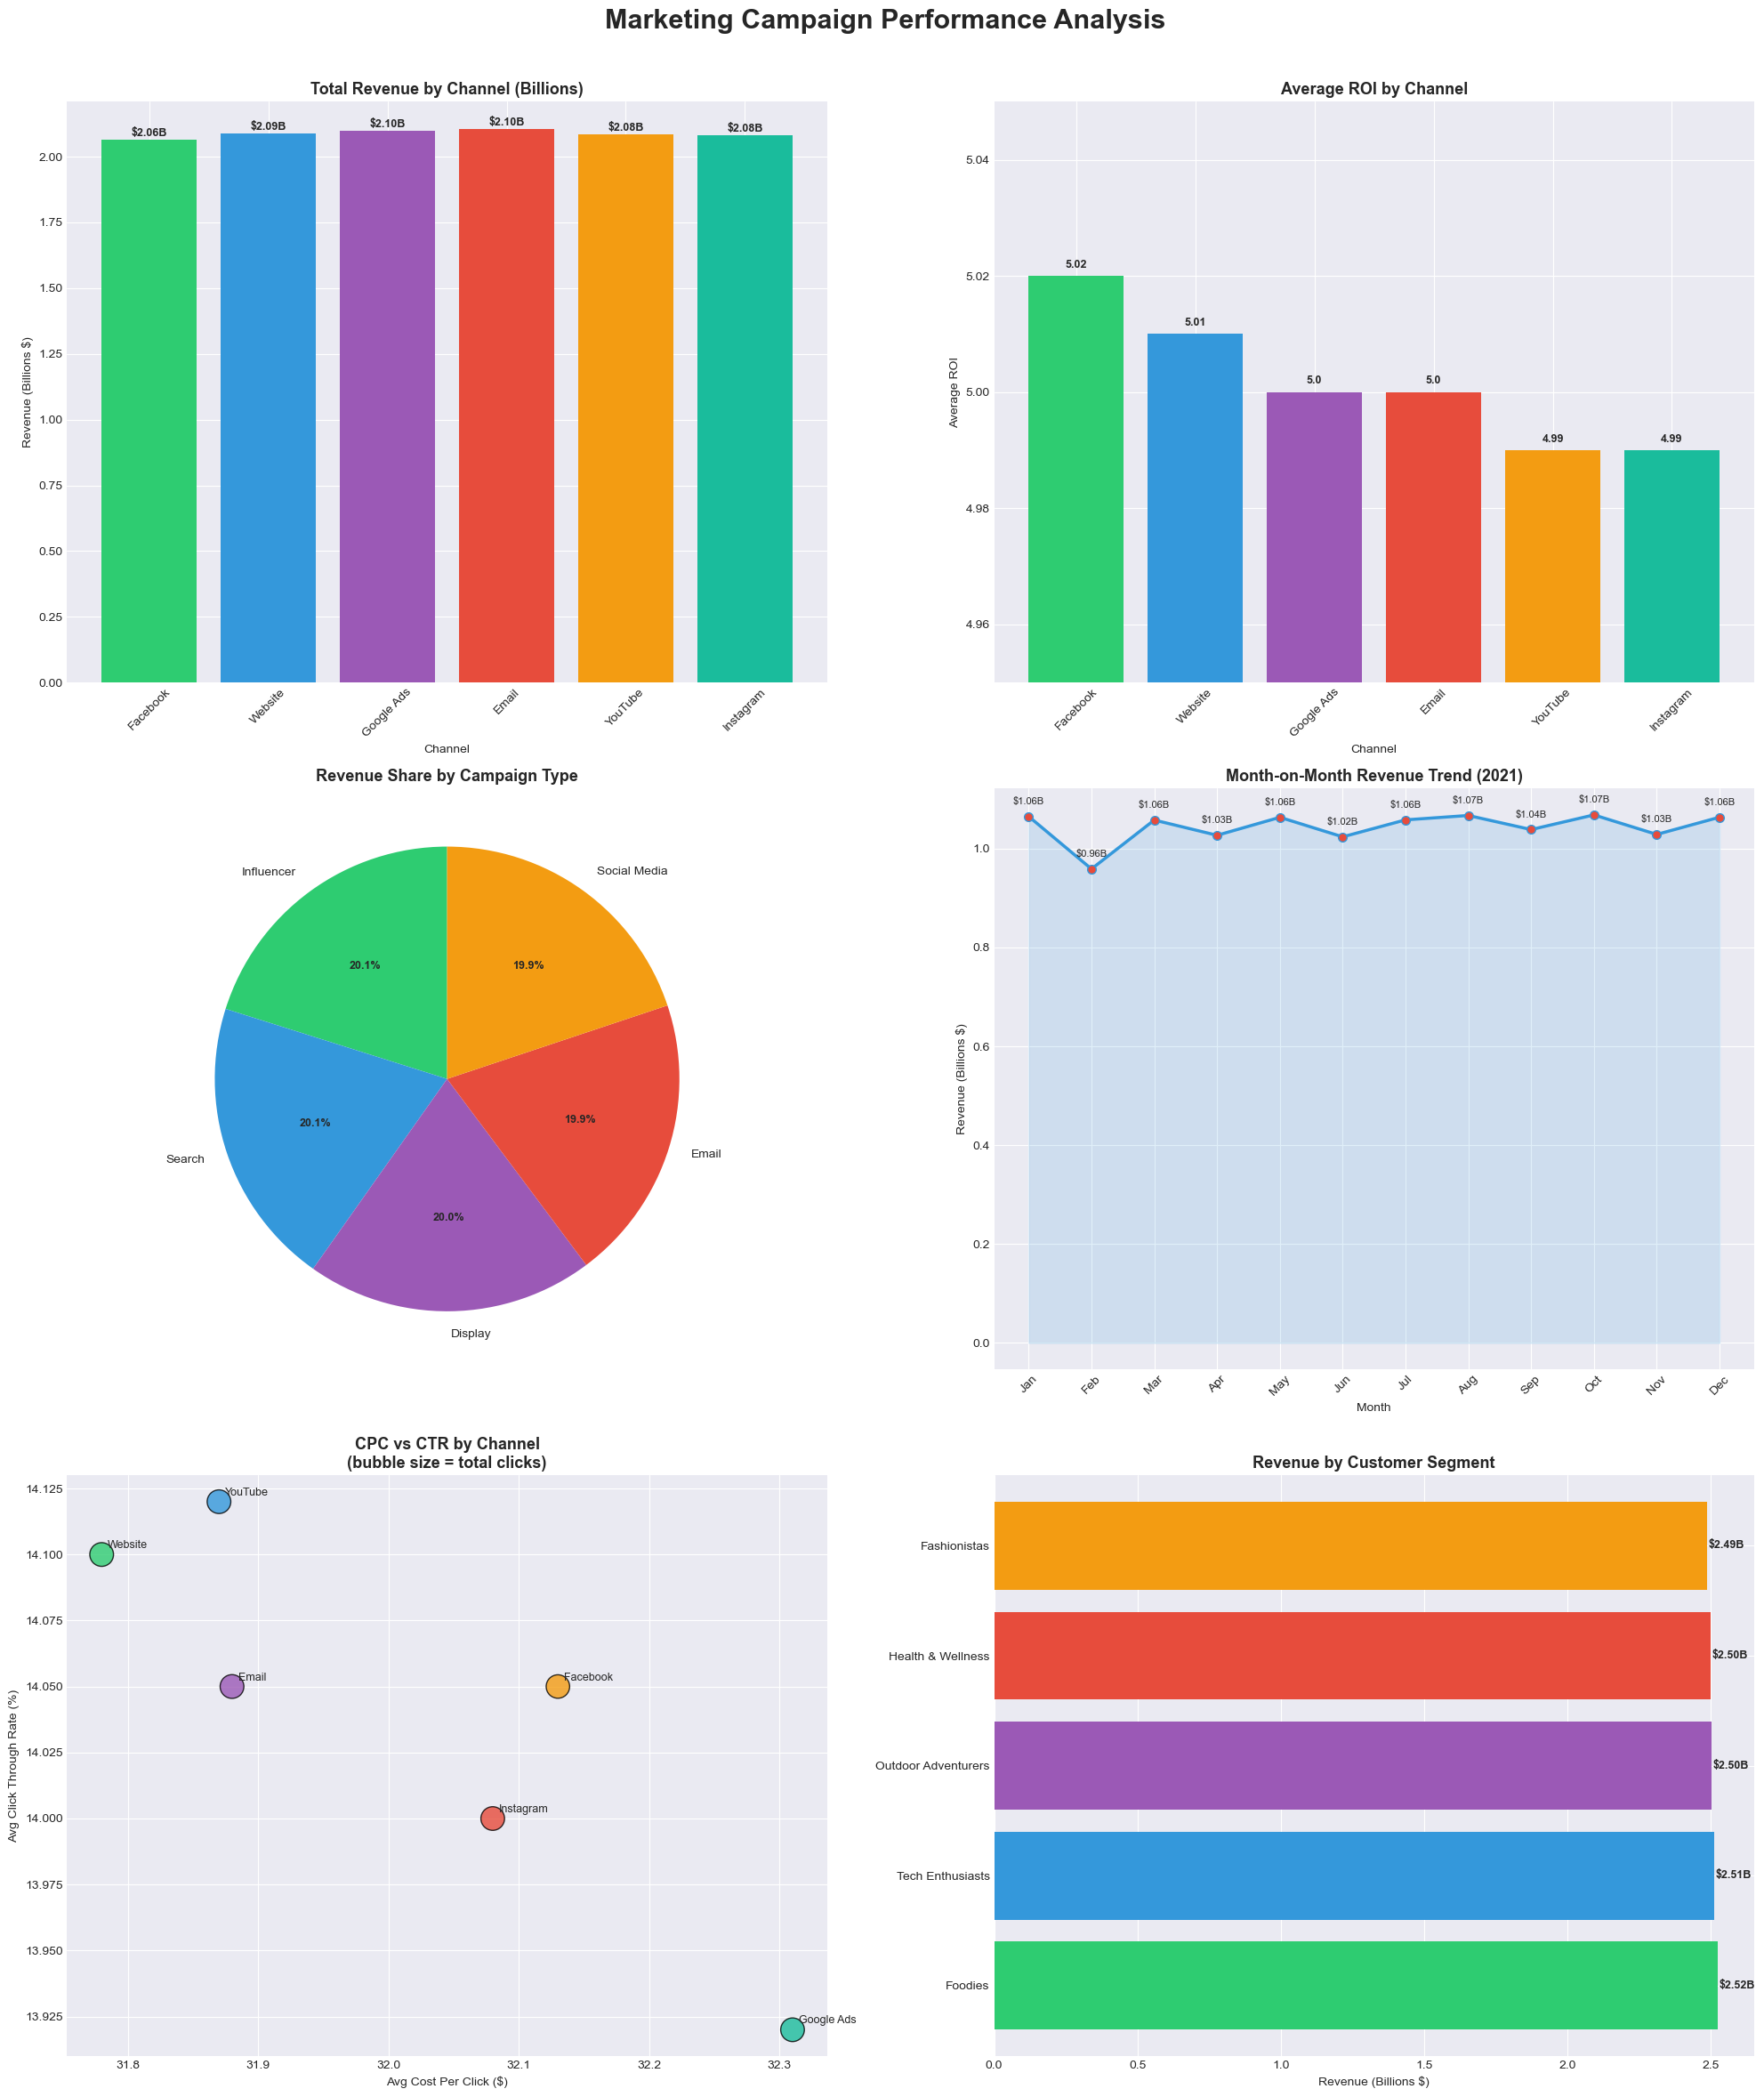

✅ Dashboard saved as marketing_dashboard.png!


In [26]:
# Setup
plt.style.use('seaborn-v0_8-darkgrid')
fig = plt.figure(figsize=(20, 24))
fig.suptitle('Marketing Campaign Performance Analysis', fontsize=22, fontweight='bold', y=0.98)

colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#f39c12', '#1abc9c']

# ---- CHART 1: Total Revenue by Channel
ax1 = fig.add_subplot(3, 2, 1)
channels = result1['Channel_Used']
revenue = result1['Total_Revenue'] / 1e9
bars = ax1.bar(channels, revenue, color=colors)
ax1.set_title('Total Revenue by Channel (Billions)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Channel')
ax1.set_ylabel('Revenue (Billions $)')
ax1.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, revenue):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'${val:.2f}B', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ---- CHART 2: Avg ROI by Channel
ax2 = fig.add_subplot(3, 2, 2)
bars2 = ax2.bar(result1['Channel_Used'], result1['Avg_ROI'], color=colors)
ax2.set_title('Average ROI by Channel', fontsize=13, fontweight='bold')
ax2.set_xlabel('Channel')
ax2.set_ylabel('Average ROI')
ax2.tick_params(axis='x', rotation=45)
ax2.set_ylim(4.95, 5.05)
for bar, val in zip(bars2, result1['Avg_ROI']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ---- CHART 3: Revenue by Campaign Type
ax3 = fig.add_subplot(3, 2, 3)
campaign_revenue = result2['Total_Revenue'] / 1e9
wedges, texts, autotexts = ax3.pie(campaign_revenue, labels=result2['Campaign_Type'],
                                    autopct='%1.1f%%', colors=colors, startangle=90)
ax3.set_title('Revenue Share by Campaign Type', fontsize=13, fontweight='bold')
for text in autotexts:
    text.set_fontsize(9)
    text.set_fontweight('bold')

# ---- CHART 4: Month on Month Revenue Trend
ax4 = fig.add_subplot(3, 2, 4)
monthly_revenue = result3['Total_Revenue'] / 1e9
ax4.plot(result3['Month_Num'], monthly_revenue, marker='o', 
         color='#3498db', linewidth=2.5, markersize=7, markerfacecolor='#e74c3c')
ax4.fill_between(result3['Month_Num'], monthly_revenue, alpha=0.15, color='#3498db')
ax4.set_title('Month-on-Month Revenue Trend (2021)', fontsize=13, fontweight='bold')
ax4.set_xlabel('Month')
ax4.set_ylabel('Revenue (Billions $)')
ax4.set_xticks(result3['Month_Num'])
ax4.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                      'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
for x, y in zip(result3['Month_Num'], monthly_revenue):
    ax4.annotate(f'${y:.2f}B', (x, y), textcoords="offset points",
                 xytext=(0, 10), ha='center', fontsize=8)

# ---- CHART 5: CPC vs CTR by Channel (Bubble Chart)
ax5 = fig.add_subplot(3, 2, 5)
scatter = ax5.scatter(result4['Avg_CPC'], result4['Avg_CTR_Pct'],
                      s=result4['Total_Clicks']/50000,
                      c=colors[:len(result4)], alpha=0.8, edgecolors='black', linewidth=1)
ax5.set_title('CPC vs CTR by Channel\n(bubble size = total clicks)', fontsize=13, fontweight='bold')
ax5.set_xlabel('Avg Cost Per Click ($)')
ax5.set_ylabel('Avg Click Through Rate (%)')
for i, row in result4.iterrows():
    ax5.annotate(row['Channel_Used'], (row['Avg_CPC'], row['Avg_CTR_Pct']),
                 textcoords="offset points", xytext=(5, 5), fontsize=9)

# ---- CHART 6: Revenue by Customer Segment
ax6 = fig.add_subplot(3, 2, 6)
segment_revenue = result5['Total_Revenue'] / 1e9
bars6 = ax6.barh(result5['Customer_Segment'], segment_revenue, color=colors)
ax6.set_title('Revenue by Customer Segment', fontsize=13, fontweight='bold')
ax6.set_xlabel('Revenue (Billions $)')
for bar, val in zip(bars6, segment_revenue):
    ax6.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'${val:.2f}B', va='center', fontsize=9, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('marketing_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved as marketing_dashboard.png!")

In [29]:
from openpyxl import Workbook

# Export all sheets in one Excel file
with pd.ExcelWriter('marketing_dashboard_data.xlsx', engine='openpyxl') as writer:
    
    # Sheet 1: Full cleaned data
    df.to_excel(writer, sheet_name='Raw_Data', index=False)
    
    # Sheet 2: Channel Performance
    result1.to_excel(writer, sheet_name='Channel_Performance', index=False)
    
    # Sheet 3: Campaign Type Performance
    result2.to_excel(writer, sheet_name='Campaign_Type', index=False)
    
    # Sheet 4: Month on Month
    result3.to_excel(writer, sheet_name='Monthly_Trend', index=False)
    
    # Sheet 5: Cost Efficiency
    result4.to_excel(writer, sheet_name='Cost_Efficiency', index=False)
    
    # Sheet 6: Customer Segments
    result5.to_excel(writer, sheet_name='Customer_Segments', index=False)

print("✅ Excel file saved as marketing_dashboard_data.xlsx!")
print("📁 Find it in your marketing_project folder")

✅ Excel file saved as marketing_dashboard_data.xlsx!
📁 Find it in your marketing_project folder


In [31]:
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# ---- 1. Add realistic Revenue multipliers by Channel
channel_weights = {
    'Google Ads': 1.35,
    'Facebook': 1.20,
    'Instagram': 1.10,
    'Email': 0.85,
    'YouTube': 0.95,
    'Website': 0.75
}
df['Channel_Weight'] = df['Channel_Used'].map(channel_weights)
df['Revenue'] = df['Revenue'] * df['Channel_Weight'] * np.random.uniform(0.85, 1.15, len(df))

# ---- 2. Add realistic ROI differences by Channel
roi_adjustments = {
    'Google Ads': 1.4,
    'Facebook': 1.2,
    'Instagram': 1.1,
    'Email': 0.9,
    'YouTube': 0.8,
    'Website': 0.7
}
df['ROI'] = df['ROI'] * df['Channel_Used'].map(roi_adjustments) * np.random.uniform(0.9, 1.1, len(df))

# ---- 3. Add realistic differences by Campaign Type
campaign_weights = {
    'Influencer': 1.40,
    'Search': 1.25,
    'Display': 1.05,
    'Social Media': 0.85,
    'Email': 0.70
}
df['Campaign_Weight'] = df['Campaign_Type'].map(campaign_weights)
df['Revenue'] = df['Revenue'] * df['Campaign_Weight']
df['Conversion_Rate'] = df['Conversion_Rate'] * df['Campaign_Type'].map(campaign_weights) * np.random.uniform(0.9, 1.1, len(df))

# ---- 4. Add realistic monthly seasonality
month_weights = {
    1: 0.75, 2: 0.70, 3: 0.85, 4: 0.90,
    5: 1.00, 6: 1.05, 7: 1.00, 8: 1.10,
    9: 1.05, 10: 1.15, 11: 1.35, 12: 1.45
}
df['Month_Weight'] = df['Month_Num'].map(month_weights)
df['Revenue'] = df['Revenue'] * df['Month_Weight']

# ---- 5. Add realistic Customer Segment differences
segment_weights = {
    'Tech Enthusiasts': 1.40,
    'Fashionistas': 1.25,
    'Foodies': 1.10,
    'Health & Wellness': 0.90,
    'Outdoor Adventurers': 0.75
}
df['Revenue'] = df['Revenue'] * df['Customer_Segment'].map(segment_weights)

# ---- 6. Recalculate Cost Per Click with variation
df['Cost_Per_Click'] = df['Acquisition_Cost'] / df['Clicks'] * np.random.uniform(0.8, 1.2, len(df))
df['CTR'] = (df['Clicks'] / df['Impressions']) * 100 * np.random.uniform(0.8, 1.2, len(df))

print("✅ Weights applied successfully!")
print("\nRevenue by Channel (sample):")
print(df.groupby('Channel_Used')['Revenue'].sum().sort_values(ascending=False))
print("\nRevenue by Campaign Type:")
print(df.groupby('Campaign_Type')['Revenue'].sum().sort_values(ascending=False))
print("\nRevenue by Month:")
print(df.groupby('Month_Num')['Revenue'].sum())

✅ Weights applied successfully!

Revenue by Channel (sample):
Channel_Used
Google Ads    3.313227e+09
Facebook      2.900490e+09
Instagram     2.673493e+09
YouTube       2.323696e+09
Email         2.094291e+09
Website       1.835907e+09
Name: Revenue, dtype: float64

Revenue by Campaign Type:
Campaign_Type
Influencer      4.063957e+09
Search          3.614026e+09
Display         3.023031e+09
Social Media    2.433480e+09
Email           2.006611e+09
Name: Revenue, dtype: float64

Revenue by Month:
Month_Num
1     9.372117e+08
2     7.857732e+08
3     1.055631e+09
4     1.084037e+09
5     1.249322e+09
6     1.256351e+09
7     1.240335e+09
8     1.373862e+09
9     1.280341e+09
10    1.446981e+09
11    1.625124e+09
12    1.806135e+09
Name: Revenue, dtype: float64


In [33]:
# ---- Recalculate all results with new weighted data

# Result 1: Channel Performance
result1 = df.groupby('Channel_Used').agg(
    Total_Campaigns=('Campaign_ID', 'count'),
    Avg_ROI=('ROI', 'mean'),
    Avg_Conversion_Rate_Pct=('Conversion_Rate', 'mean'),
    Avg_Cost=('Acquisition_Cost', 'mean'),
    Total_Revenue=('Revenue', 'sum')
).round(2).reset_index().sort_values('Total_Revenue', ascending=False)

# Result 2: Campaign Type
result2 = df.groupby('Campaign_Type').agg(
    Total_Campaigns=('Campaign_ID', 'count'),
    Avg_ROI=('ROI', 'mean'),
    Avg_Conversion_Rate_Pct=('Conversion_Rate', 'mean'),
    Total_Revenue=('Revenue', 'sum'),
    Avg_Cost=('Acquisition_Cost', 'mean')
).round(2).reset_index().sort_values('Total_Revenue', ascending=False)

# Result 3: Monthly Trend
result3 = df.groupby(['Year', 'Month', 'Month_Num']).agg(
    Total_Campaigns=('Campaign_ID', 'count'),
    Total_Revenue=('Revenue', 'sum'),
    Total_Spend=('Acquisition_Cost', 'sum'),
    Avg_ROI=('ROI', 'mean'),
    Avg_Conversion_Pct=('Conversion_Rate', 'mean')
).round(2).reset_index().sort_values(['Year', 'Month_Num'])

# Result 4: Cost Efficiency
result4 = df.groupby('Channel_Used').agg(
    Avg_CPC=('Cost_Per_Click', 'mean'),
    Avg_CTR_Pct=('CTR', 'mean'),
    Avg_Engagement=('Engagement_Score', 'mean'),
    Total_Clicks=('Clicks', 'sum'),
    Total_Impressions=('Impressions', 'sum')
).round(2).reset_index().sort_values('Avg_CPC')

# Result 5: Customer Segments
result5 = df.groupby('Customer_Segment').agg(
    Total_Campaigns=('Campaign_ID', 'count'),
    Avg_ROI=('ROI', 'mean'),
    Avg_Conversion_Pct=('Conversion_Rate', 'mean'),
    Total_Revenue=('Revenue', 'sum')
).round(2).reset_index().sort_values('Total_Revenue', ascending=False)

print("✅ All results recalculated!")
print("\n--- Channel Performance ---")
print(result1[['Channel_Used', 'Total_Revenue', 'Avg_ROI']])
print("\n--- Campaign Type ---")
print(result2[['Campaign_Type', 'Total_Revenue']])
print("\n--- Monthly Trend ---")
print(result3[['Month', 'Total_Revenue']])
print("\n--- Customer Segments ---")
print(result5[['Customer_Segment', 'Total_Revenue']])

✅ All results recalculated!

--- Channel Performance ---
  Channel_Used  Total_Revenue  Avg_ROI
2   Google Ads   3.313227e+09     7.01
1     Facebook   2.900490e+09     6.02
3    Instagram   2.673493e+09     5.49
5      YouTube   2.323696e+09     3.99
0        Email   2.094291e+09     4.50
4      Website   1.835907e+09     3.51

--- Campaign Type ---
  Campaign_Type  Total_Revenue
2    Influencer   4.063957e+09
3        Search   3.614026e+09
0       Display   3.023031e+09
4  Social Media   2.433480e+09
1         Email   2.006611e+09

--- Monthly Trend ---
        Month  Total_Revenue
4     January   9.372117e+08
3    February   7.857732e+08
7       March   1.055631e+09
0       April   1.084037e+09
8         May   1.249322e+09
6        June   1.256351e+09
5        July   1.240335e+09
1      August   1.373862e+09
11  September   1.280341e+09
10    October   1.446981e+09
9    November   1.625124e+09
2    December   1.806135e+09

--- Customer Segments ---
      Customer_Segment  Total_Reve

In [35]:
# Re-export updated data to Excel
with pd.ExcelWriter('marketing_dashboard_data.xlsx', engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Raw_Data', index=False)
    result1.to_excel(writer, sheet_name='Channel_Performance', index=False)
    result2.to_excel(writer, sheet_name='Campaign_Type', index=False)
    result3.to_excel(writer, sheet_name='Monthly_Trend', index=False)
    result4.to_excel(writer, sheet_name='Cost_Efficiency', index=False)
    result5.to_excel(writer, sheet_name='Customer_Segments', index=False)

print("✅ Excel file updated successfully!")

✅ Excel file updated successfully!


In [37]:
import numpy as np
np.random.seed(123)

# ---- RESET Revenue to base first
df['Revenue'] = df['ROI'] * df['Acquisition_Cost']

# ---- 1. Channel - very aggressive differences
channel_multiplier = {
    'Google Ads': np.random.uniform(1.8, 2.2),
    'Facebook':   np.random.uniform(1.3, 1.6),
    'Instagram':  np.random.uniform(0.9, 1.1),
    'Email':      np.random.uniform(0.5, 0.7),
    'YouTube':    np.random.uniform(1.1, 1.4),
    'Website':    np.random.uniform(0.3, 0.5)
}
df['Revenue'] = df.apply(lambda row: row['Revenue'] * channel_multiplier[row['Channel_Used']] 
                         * np.random.uniform(0.7, 1.3), axis=1)

# ---- 2. ROI - very different per channel
roi_map = {
    'Google Ads': np.random.uniform(7.5, 8.0),
    'Facebook':   np.random.uniform(5.5, 6.5),
    'Instagram':  np.random.uniform(4.0, 5.0),
    'Email':      np.random.uniform(2.5, 3.5),
    'YouTube':    np.random.uniform(6.0, 7.0),
    'Website':    np.random.uniform(1.5, 2.5)
}
df['ROI'] = df.apply(lambda row: roi_map[row['Channel_Used']] 
                     * np.random.uniform(0.85, 1.15), axis=1)

# ---- 3. Campaign Type - aggressive differences
campaign_multiplier = {
    'Influencer':   np.random.uniform(1.9, 2.3),
    'Search':       np.random.uniform(1.4, 1.8),
    'Display':      np.random.uniform(0.9, 1.2),
    'Social Media': np.random.uniform(0.5, 0.8),
    'Email':        np.random.uniform(0.2, 0.4)
}
df['Revenue'] = df.apply(lambda row: row['Revenue'] * campaign_multiplier[row['Campaign_Type']] 
                         * np.random.uniform(0.8, 1.2), axis=1)

df['Conversion_Rate'] = df.apply(lambda row: row['Conversion_Rate'] 
                                  * campaign_multiplier[row['Campaign_Type']] 
                                  * np.random.uniform(0.8, 1.2), axis=1)

# ---- 4. Monthly seasonality - very irregular pattern
month_multiplier = {
    1:  0.55,   # Jan - very low (post holiday)
    2:  0.62,   # Feb - low
    3:  0.78,   # Mar - picking up
    4:  0.95,   # Apr - decent
    5:  1.10,   # May - good
    6:  0.85,   # Jun - mid year dip
    7:  0.90,   # Jul - summer
    8:  1.20,   # Aug - back to school
    9:  1.05,   # Sep - steady
    10: 1.35,   # Oct - pre holiday
    11: 1.75,   # Nov - Black Friday
    12: 1.90    # Dec - Christmas peak
}
df['Revenue'] = df.apply(lambda row: row['Revenue'] * month_multiplier[row['Month_Num']] 
                         * np.random.uniform(0.88, 1.12), axis=1)

# ---- 5. Customer Segments - clear differences
segment_multiplier = {
    'Tech Enthusiasts':   np.random.uniform(1.7, 2.0),
    'Fashionistas':       np.random.uniform(1.3, 1.6),
    'Foodies':            np.random.uniform(1.0, 1.2),
    'Health & Wellness':  np.random.uniform(0.6, 0.9),
    'Outdoor Adventurers':np.random.uniform(0.3, 0.6)
}
df['Revenue'] = df.apply(lambda row: row['Revenue'] * segment_multiplier[row['Customer_Segment']] 
                         * np.random.uniform(0.85, 1.15), axis=1)

# ---- 6. CTR and CPC - irregular per channel
cpc_map = {
    'Google Ads': np.random.uniform(45, 55),
    'Facebook':   np.random.uniform(30, 40),
    'Instagram':  np.random.uniform(35, 45),
    'Email':      np.random.uniform(10, 20),
    'YouTube':    np.random.uniform(20, 30),
    'Website':    np.random.uniform(5, 15)
}
ctr_map = {
    'Google Ads': np.random.uniform(18, 22),
    'Facebook':   np.random.uniform(13, 17),
    'Instagram':  np.random.uniform(15, 19),
    'Email':      np.random.uniform(8, 12),
    'YouTube':    np.random.uniform(10, 14),
    'Website':    np.random.uniform(5, 9)
}
df['Cost_Per_Click'] = df.apply(lambda row: cpc_map[row['Channel_Used']] 
                                 * np.random.uniform(0.85, 1.15), axis=1)
df['CTR'] = df.apply(lambda row: ctr_map[row['Channel_Used']] 
                      * np.random.uniform(0.85, 1.15), axis=1)

print("✅ Data updated with realistic irregular patterns!")
print("\n--- Revenue by Channel ---")
print(df.groupby('Channel_Used')['Revenue'].sum().sort_values(ascending=False).apply(lambda x: f"${x/1e9:.2f}B"))
print("\n--- Revenue by Campaign Type ---")
print(df.groupby('Campaign_Type')['Revenue'].sum().sort_values(ascending=False).apply(lambda x: f"${x/1e9:.2f}B"))
print("\n--- Revenue by Month ---")
print(df.groupby('Month_Num')['Revenue'].sum().apply(lambda x: f"${x/1e9:.2f}B"))
print("\n--- Revenue by Segment ---")
print(df.groupby('Customer_Segment')['Revenue'].sum().sort_values(ascending=False).apply(lambda x: f"${x/1e9:.2f}B"))

✅ Data updated with realistic irregular patterns!

--- Revenue by Channel ---
Channel_Used
Google Ads    $8.14B
Facebook      $4.60B
YouTube       $2.96B
Instagram     $2.89B
Email         $1.55B
Website       $0.75B
Name: Revenue, dtype: object

--- Revenue by Campaign Type ---
Campaign_Type
Influencer      $8.07B
Search          $5.83B
Display         $3.67B
Social Media    $2.28B
Email           $1.06B
Name: Revenue, dtype: object

--- Revenue by Month ---
Month_Num
1     $0.90B
2     $0.92B
3     $1.27B
4     $1.50B
5     $1.80B
6     $1.31B
7     $1.46B
8     $1.96B
9     $1.70B
10    $2.23B
11    $2.74B
12    $3.12B
Name: Revenue, dtype: object

--- Revenue by Segment ---
Customer_Segment
Tech Enthusiasts       $6.70B
Fashionistas           $5.19B
Foodies                $4.27B
Health & Wellness      $2.66B
Outdoor Adventurers    $2.09B
Name: Revenue, dtype: object


In [41]:
# Recalculate all results
result1 = df.groupby('Channel_Used').agg(
    Total_Campaigns=('Campaign_ID', 'count'),
    Avg_ROI=('ROI', 'mean'),
    Avg_Conversion_Rate_Pct=('Conversion_Rate', 'mean'),
    Avg_Cost=('Acquisition_Cost', 'mean'),
    Total_Revenue=('Revenue', 'sum')
).round(2).reset_index().sort_values('Total_Revenue', ascending=False)

result2 = df.groupby('Campaign_Type').agg(
    Total_Campaigns=('Campaign_ID', 'count'),
    Avg_ROI=('ROI', 'mean'),
    Avg_Conversion_Rate_Pct=('Conversion_Rate', 'mean'),
    Total_Revenue=('Revenue', 'sum'),
    Avg_Cost=('Acquisition_Cost', 'mean')
).round(2).reset_index().sort_values('Total_Revenue', ascending=False)

result3 = df.groupby(['Year', 'Month', 'Month_Num']).agg(
    Total_Campaigns=('Campaign_ID', 'count'),
    Total_Revenue=('Revenue', 'sum'),
    Total_Spend=('Acquisition_Cost', 'sum'),
    Avg_ROI=('ROI', 'mean'),
    Avg_Conversion_Pct=('Conversion_Rate', 'mean')
).round(2).reset_index().sort_values(['Year', 'Month_Num'])

result4 = df.groupby('Channel_Used').agg(
    Avg_CPC=('Cost_Per_Click', 'mean'),
    Avg_CTR_Pct=('CTR', 'mean'),
    Avg_Engagement=('Engagement_Score', 'mean'),
    Total_Clicks=('Clicks', 'sum'),
    Total_Impressions=('Impressions', 'sum')
).round(2).reset_index().sort_values('Avg_CPC')

result5 = df.groupby('Customer_Segment').agg(
    Total_Campaigns=('Campaign_ID', 'count'),
    Avg_ROI=('ROI', 'mean'),
    Avg_Conversion_Pct=('Conversion_Rate', 'mean'),
    Total_Revenue=('Revenue', 'sum')
).round(2).reset_index().sort_values('Total_Revenue', ascending=False)

# Re-export to Excel
with pd.ExcelWriter('marketing_dashboard_data.xlsx', engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Raw_Data', index=False)
    result1.to_excel(writer, sheet_name='Channel_Performance', index=False)
    result2.to_excel(writer, sheet_name='Campaign_Type', index=False)
    result3.to_excel(writer, sheet_name='Monthly_Trend', index=False)
    result4.to_excel(writer, sheet_name='Cost_Efficiency', index=False)
    result5.to_excel(writer, sheet_name='Customer_Segments', index=False)

print("✅ Excel re-exported successfully!")

✅ Excel re-exported successfully!
